<a href="https://colab.research.google.com/github/kjian254416-blip/ML300/blob/main/Chapter_1_%EC%9E%90%EB%8F%99%EC%9C%BC%EB%A1%9C_%EB%AA%A8%EC%9D%80_%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%8A%94_%EB%B6%84%EC%84%9D%ED%95%98%EA%B8%B0_%EC%96%B4%EB%A0%B5%EB%8B%A4%EB%A9%B4%EC%84%9C__%EC%9E%90%EB%8F%99%EC%9C%BC%EB%A1%9C_%EB%AA%A8%EC%9D%80_%EC%A4%91%EA%B3%A0_%EC%9E%90%EB%8F%99%EC%B0%A8_%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%A5%BC_%EB%B6%84%EC%84%9D%ED%95%B4%EB%B3%B4%EC%9E%90!(%EB%AC%B8%EC%A0%9C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주제 : 자동으로 모은 데이터는 분석하기 어렵다면서? 자동으로 모은 중고 자동차 데이터를 분석해보자!
----------

## 실습 가이드
    1. 데이터를 다운로드하여 Colab에 불러옵니다.
    2. 필요한 라이브러리는 모두 코드로 작성되어 있습니다.
    3. 코드는 위에서부터 아래로 순서대로 실행합니다.
    
    
## 데이터 소개
    - 이번 주제는 Used Cars Dataset을 사용합니다.
    - 파일은 한 개이며, 각각의 컬럼은 아래와 같습니다.
    
    - vehicles.csv
    id : 중고차 거래의 아이디
    url : 중고차 거래 페이지
    region : 해당 거래의 관리 지점
    region_url : 거래 관리 지점의 홈페이지
    price : 기입된 자동차의 거래가
    year : 거래가 기입된 년도
    manufacturer : 자동차를 생산한 회사
    model : 자동차 모델명
    condition : 자동차의 상태
    cylinders : 자동차의 기통 수
    fuel : 자동차의 연료 타입
    odometer : 자동차의 운행 마일 수
    title_status : 자동차의 타이틀 상태 (소유주 등록 상태)
    transmission : 자동차의 트랜스미션 종류
    vin : 자동차의 식별 번호 (vehicle identification number)
    drive : 자동차의 구동 타입
    size : 자동차 크기
    type : 자동차의 일반 타입 (세단, ...)
    paint_color : 자동차 색상
    image_url : 자동차 이미지
    description : 세부 설명
    county : 실수로 생성된 미사용 컬럼
    state : 거래가 업로드된 미 주
    lat : 거래가 업로드된 곳의 위도
    long : 거래가 업로드된 곳의 경도
    
    
- 데이터 출처: https://www.kaggle.com/austinreese/craigslist-carstrucks-data

## 최종 목표
    - 스크래핑된 dirty 데이터 클리닝 방법 이해
    - 다양한 종류의 데이터 정규화 방법 습득
    - 데이터 시각화를 통한 인사이트 습득 방법의 이해
    - Scikit-learn 기반의 모델 학습 방법 습득
    - XGBoost, LightGBM 기반의 모델 학습 방법 습득
    - 학습된 모델의 평가 방법 및 시각화 방법 습득

- 출제자 : 신제용 강사
---

## Step 0. 데이터 스크래핑이 대하여

데이터 자동으로 긁어모으는 것

### 스크래핑을 이용한 자동 데이터 습득

데이터의 형식을 예측,고정적으로 지정

### 스크래핑된 데이터에서 아웃라이어의 특징


빈데이터가 많고 형식이 틀린경우가 많음

## Step 1. 데이터셋 준비하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 문제 1. Colab Notebook에 Kaggle API 세팅하기


In [2]:
import os

In [3]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기

os.environ['KAGGLE_USERNAME'] = 'kimjian254416'
os.environ['KAGGLE_KEY'] = '0457ef800614319f99e6b8144bfd741e'


### 문제 2. 데이터 다운로드 및 압축 해제하기


In [5]:
# Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기 (!kaggle ~)
# Linux 명령어로 압축 해제하기

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "vehicles.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "austinreese/craigslist-carstrucks-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())



/tmp/ipykernel_767/3299321776.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'craigslist-carstrucks-data' dataset.
First 5 records:            id                                                url  \
0  7222695916  https://prescott.craigslist.org/cto/d/prescott...   
1  7218891961  https://fayar.craigslist.org/ctd/d/bentonville...   
2  7221797935  https://keys.craigslist.org/cto/d/summerland-k...   
3  7222270760  https://worcester.craigslist.org/cto/d/west-br...   
4  7210384030  https://greensboro.craigslist.org/cto/d/trinit...   

                   region                         region_url  price  year  \
0                prescott    https://prescott.craigslist.org   6000   NaN   
1            fayetteville       https://fayar.craigslist.org  11900   NaN   
2            florida keys        https://keys.craigslist.org  21000   NaN   
3  worcester / central MA   https://worcester.craigslist.org   1500   NaN   
4              greensboro  https://greensboro.craigslist.org   4900   NaN   

  manufacturer model condition

In [7]:
!rm *.*
!kaggle datasets download -d austinreese/craigslist-carstrucks-data
!unzip '*.zip'

rm: cannot remove '*.*': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
License(s): CC0-1.0
100% 262M/262M [00:01<00:00, 141MB/s]

Archive:  craigslist-carstrucks-data.zip
  inflating: vehicles.csv            


In [8]:
df = pd.read_csv('vehicles.csv')

### 문제 3. Pandas 라이브러리로 csv파일 읽어들이기


In [6]:
df

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [12]:
df.isna().sum()

,0
id,0
url,0
region,0
region_url,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678


In [13]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [14]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [16]:
df.drop([ 'id', 'url', 'region_url'
       , 'VIN',
       'image_url', 'description', 'state', 'lat', 'long',
       'posting_date' ],axis=1,inplace=True)

In [17]:
df['age']=2026-df['year']
df.drop('year',axis=1,inplace=True)

In [18]:
df

,region,price,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,county,age
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,wyoming,23590,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,NaN,sedan,NaN,NaN,7.0
426876,wyoming,30590,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,NaN,sedan,red,NaN,6.0
426877,wyoming,34990,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,NaN,hatchback,white,NaN,6.0
426878,wyoming,28990,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,NaN,sedan,silver,NaN,8.0


## Step 2. EDA 및 데이터 기초 통계 분석


### 문제 4. 불필요한 데이터 데이터프레임에서 제거하기


In [9]:
# DataFrame에서 제공하는 메소드를 이용하여 각 데이터프레임의 구조 분석하기 (head(), info(), describe())
# 데이터프레임에서 불필요한 컬럼 제거하기

df.head()


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


### 문제 5. 범주형 데이터의 통계 분석하기


In [19]:
df.columns

Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'county', 'age'],
      dtype='object')

In [21]:
df.drop(['county'],axis=1,inplace=True)

In [23]:
# 범주형 데이터의 값의 범위, 기초 통계 분석하기

len(df['manufacturer'].value_counts())


42

In [24]:
df['manufacturer'].value_counts()

,count
manufacturer,
ford,70985
chevrolet,55064
toyota,34202
honda,21269
nissan,19067
jeep,19014
ram,18342
gmc,16785
bmw,14699


<Axes: xlabel='count', ylabel='manufacturer'>

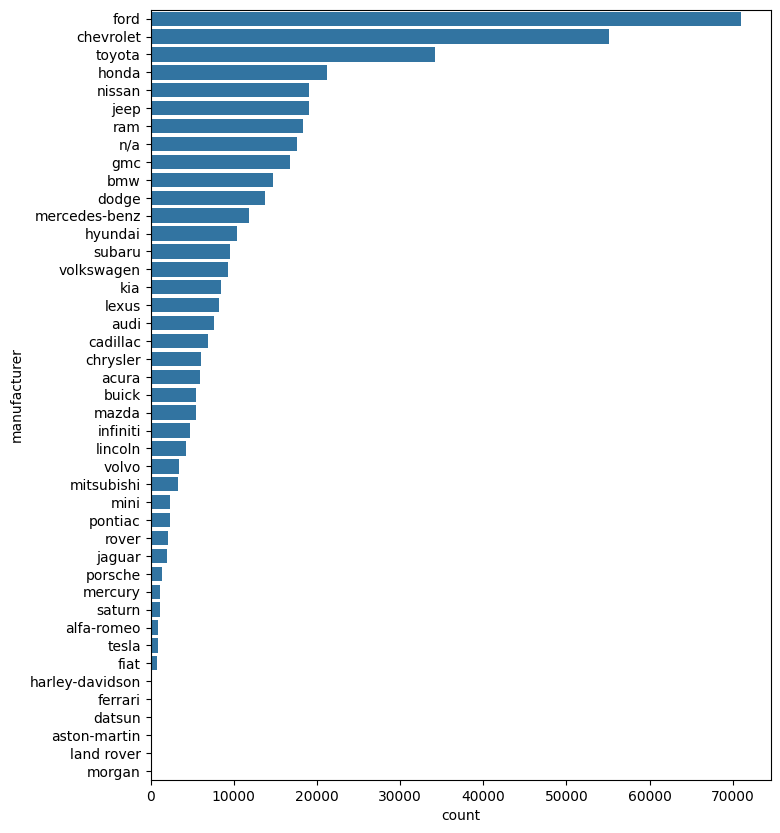

In [28]:
#분포를 보고싶을 때 countplot으로
fig = plt.figure(figsize=(8,10))
sns.countplot(y='manufacturer',data=df.fillna('n/a'),order=df.fillna('n/a')['manufacturer'].value_counts().index)

In [29]:
df.columns

Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'age'],
      dtype='object')

In [30]:
for model,num in zip(df['model'].value_counts().index,df['model'].value_counts()):
  print(model,num)

f-150 8009
silverado 1500 5140
1500 4211
camry 3135
silverado 3023
accord 2969
wrangler 2848
civic 2799
altima 2779
escape 2746
2500 2687
tacoma 2582
explorer 2499
grand cherokee 2489
corolla 2241
mustang 2225
fusion 1979
equinox 1972
cr-v 1930
focus 1832
malibu 1764
tahoe 1729
charger 1719
corvette 1711
rav4 1701
sonata 1686
impala 1682
sierra 1500 1658
grand caravan 1601
cruze 1559
outback 1551
silverado 2500hd 1545
f-250 1529
elantra 1498
odyssey 1494
3500 1491
edge 1471
prius 1435
tundra 1425
jetta 1384
rogue 1332
forester 1318
sentra 1288
sierra 1282
wrangler unlimited 1273
camaro 1159
soul 1137
pilot 1118
c-class 1117
sienna 1116
f-350 1116
f150 1089
cherokee 1078
4runner 1073
highlander 1068
suburban 1066
expedition 1058
traverse 985
impreza 960
optima 958
challenger 953
acadia 925
3 series 917
sierra 2500hd 895
e-class 885
yukon 884
x5 880
santa fe 826
taurus 820
200 817
ranger 813
terrain 801
colorado 798
durango 794
f250 791
mdx 791
sorento 790
journey 779
escalade 773
passat

In [33]:
fig = plt.figure(figsize=(8,10))
sns.countplot(y='model',data = df.fillna('n/a'),order=df.fillna('n/a')['model'].value_counts().index)

<Axes: xlabel='count', ylabel='model'>

Error in callback <function _draw_all_if_interactive at 0x7ab6929dd120> (for post_execute):


ValueError: 
1500 laramie, $452.02 month, 2.9% apr, $2000 down, 72 m laramie, $452.02 month, 2.9% apr, $2000 down, 72 m
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

ValueError: 
1500 laramie, $452.02 month, 2.9% apr, $2000 down, 72 m laramie, $452.02 month, 2.9% apr, $2000 down, 72 m
              ^
ParseException: Expected end of text, found '$'  (at char 14), (line:1, col:15)

<Figure size 800x1000 with 1 Axes>

<Axes: xlabel='count', ylabel='condition'>

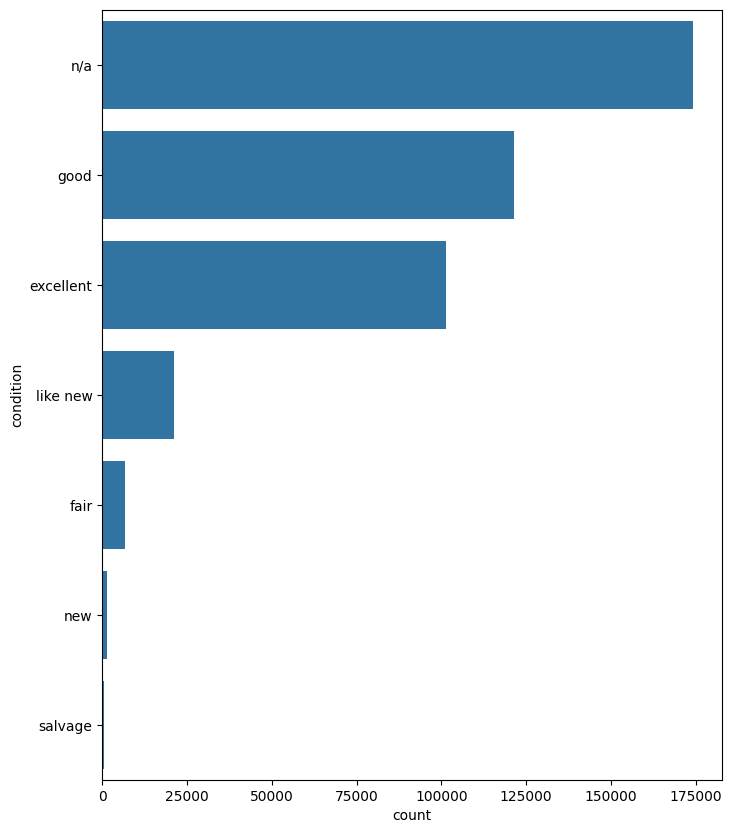

In [34]:
fig = plt.figure(figsize=(8,10))
sns.countplot(y='condition',data = df.fillna('n/a'),order=df.fillna('n/a')['condition'].value_counts().index)

<Axes: xlabel='count', ylabel='cylinders'>

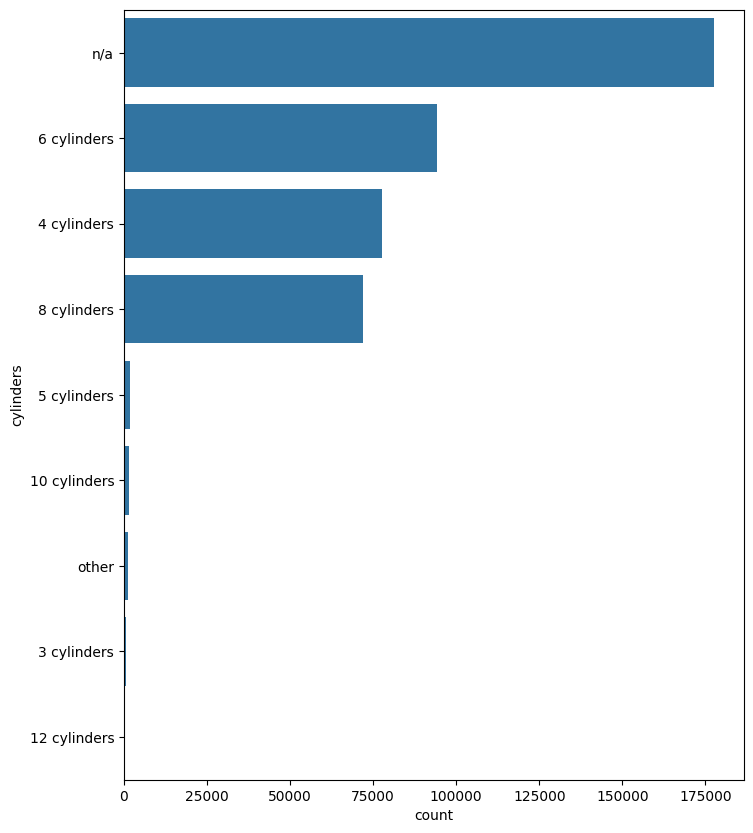

In [36]:
fig = plt.figure(figsize=(8,10))
sns.countplot(y='cylinders',data = df.fillna('n/a'),order=df.fillna('n/a')['cylinders'].value_counts().index)

<Axes: xlabel='count', ylabel='fuel'>

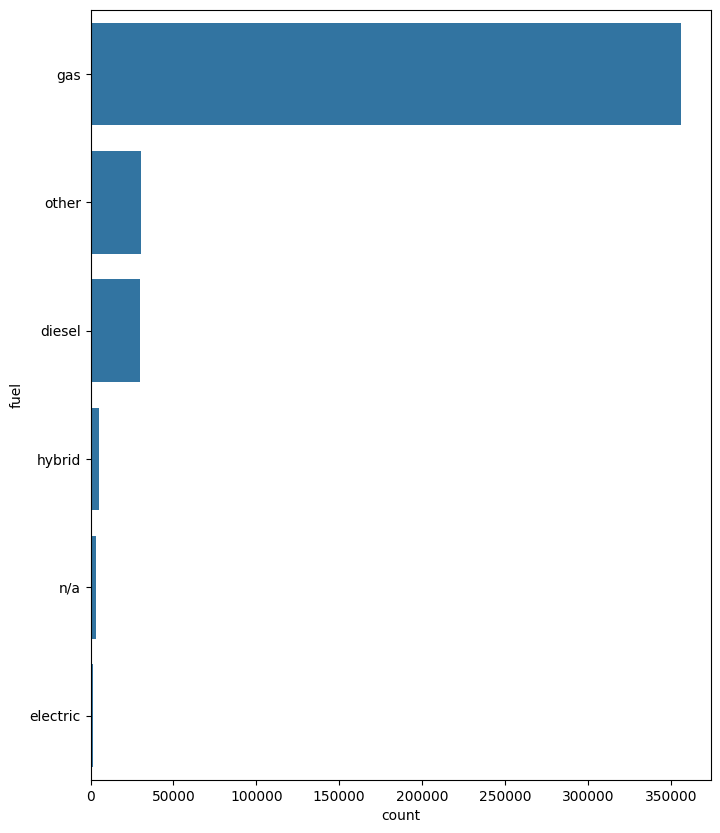

In [37]:
fig = plt.figure(figsize=(8,10))
sns.countplot(y='fuel',data = df.fillna('n/a'),order=df.fillna('n/a')['fuel'].value_counts().index)

In [38]:
df.columns

Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'age'],
      dtype='object')

<Axes: xlabel='count', ylabel='transmission'>

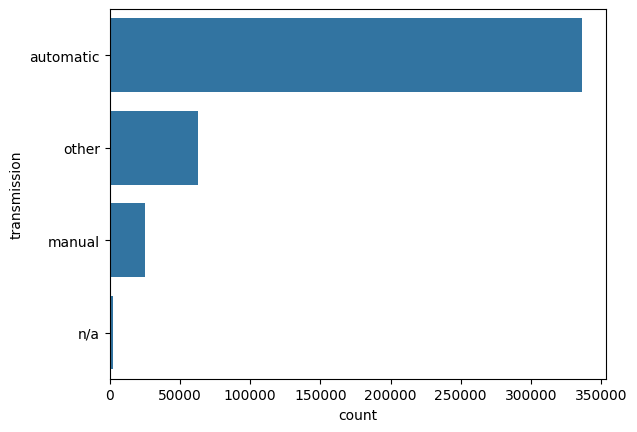

In [39]:
sns.countplot(y='transmission',data = df.fillna('n/a'),order=df.fillna('n/a')['transmission'].value_counts().index)

<Axes: xlabel='count', ylabel='drive'>

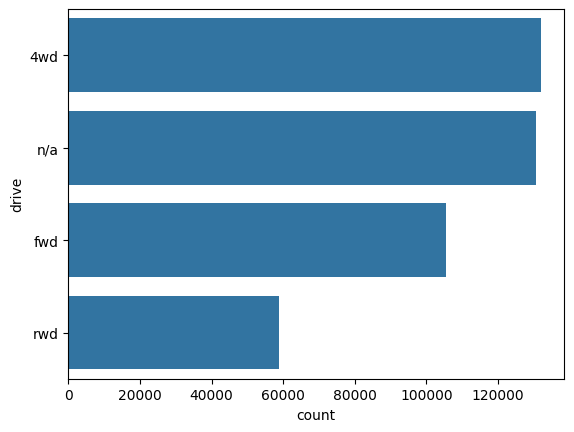

In [40]:
sns.countplot(y='drive',data = df.fillna('n/a'),order=df.fillna('n/a')['drive'].value_counts().index)

<Axes: xlabel='count', ylabel='size'>

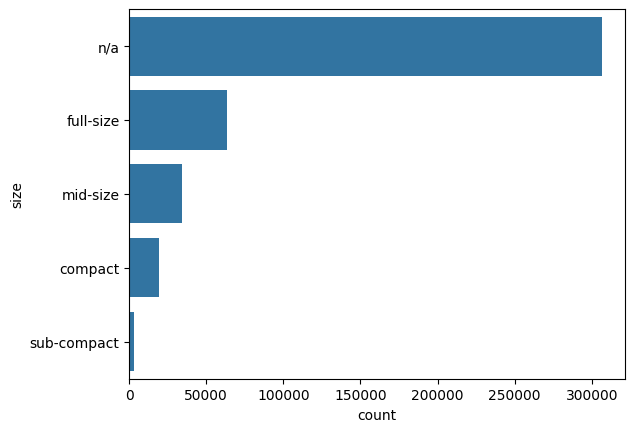

In [41]:
sns.countplot(y='size',data = df.fillna('n/a'),order=df.fillna('n/a')['size'].value_counts().index)

<Axes: xlabel='count', ylabel='type'>

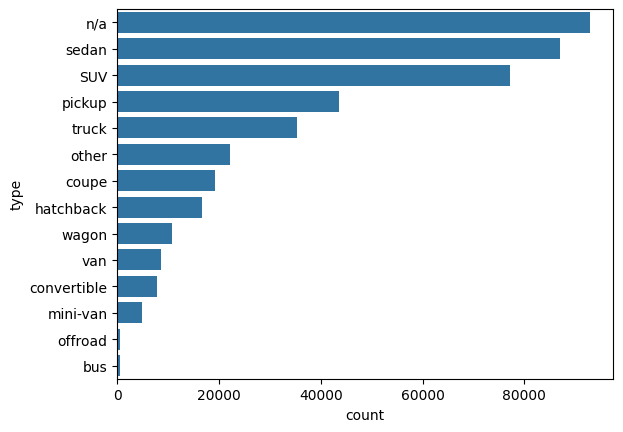

In [42]:
sns.countplot(y='type',data = df.fillna('n/a'),order=df.fillna('n/a')['type'].value_counts().index)

<Axes: xlabel='count', ylabel='paint_color'>

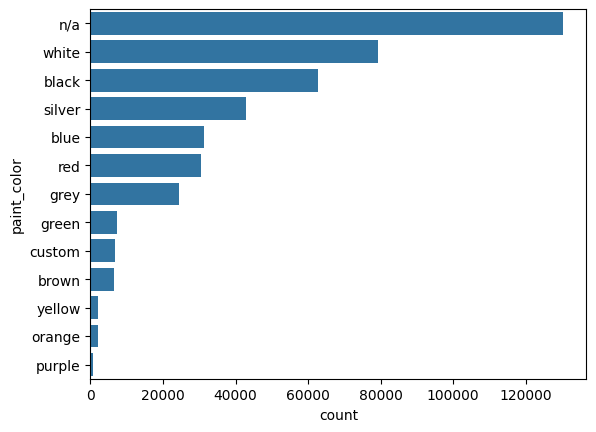

In [43]:
sns.countplot(y='paint_color',data = df.fillna('n/a'),order=df.fillna('n/a')['paint_color'].value_counts().index)

### 문제 6. 수치형 데이터의 통계 분석하기

In [45]:
# 수치형 데이터의 값의 범위, 기초 통계 분석하기


df.columns



Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'age'],
      dtype='object')

<Axes: xlabel='price'>

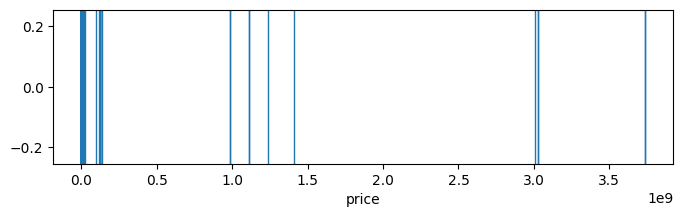

In [53]:
fig = plt.figure(figsize=(8,2))
sns.rugplot(x='price',data=df,height=1)

<Axes: xlabel='odometer'>

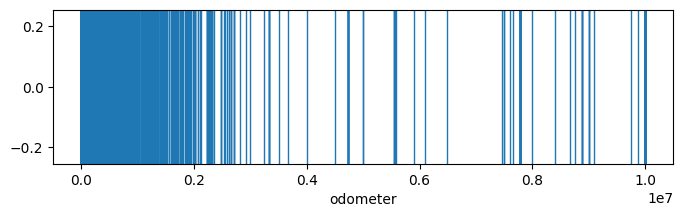

In [56]:
fig = plt.figure(figsize=(8,2))
sns.rugplot(x='odometer',data=df,height=1)

<Axes: xlabel='age', ylabel='Count'>

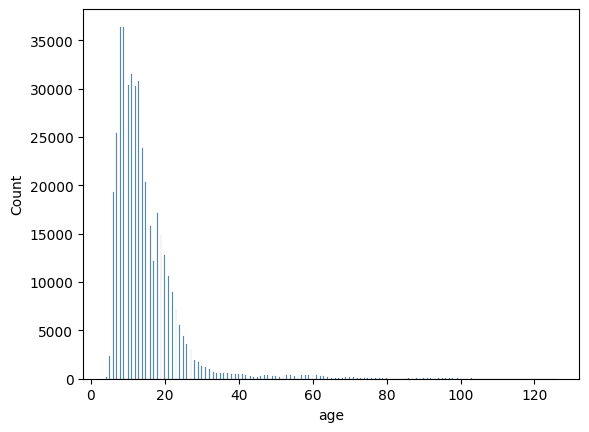

In [49]:
sns.histplot(x='age',data=df,bins=10,kde=True)

## Step 3. 데이터 클리닝 수행하기

### 문제 7. 범주형 데이터 시각화하여 분석하기

<Axes: xlabel='manufacturer', ylabel='price'>

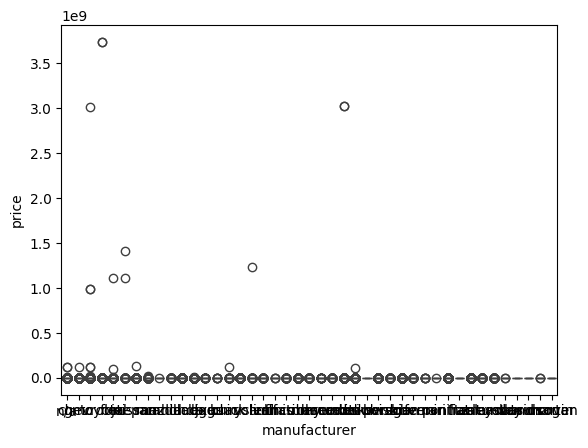

In [58]:
# Boxplot 계열로 범주형 데이터를 시각화하여 분석하기

sns.boxplot(x='manufacturer',y = 'price',data=df.fillna('n/a'))

<Axes: xlabel='fuel', ylabel='price'>

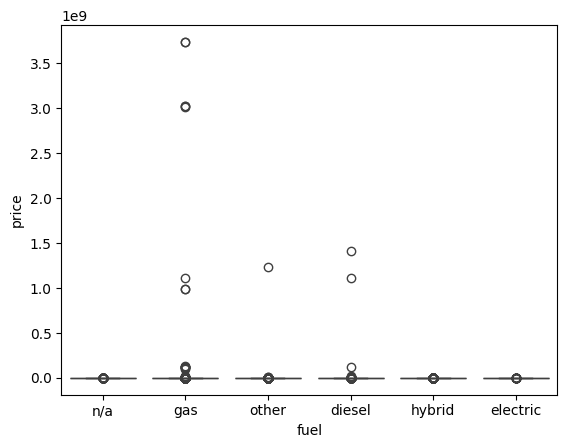

In [60]:
sns.boxplot(x='fuel',y = 'price',data=df.fillna('n/a'))

### 문제 8. 범주형 데이터 클리닝하기

In [84]:
df.drop('title_status',axis=1,inplace=True)

In [61]:
df.columns

Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'age'],
      dtype='object')

In [62]:
# 범주형 데이터를 아래 방법 중 적절히 판단하여 처리하기
# 1. 결손 데이터가 포함된 Row를 제거
# 2. 결손 데이터를 others 범주로 변경하기
# 3. 지나치게 소수로 이루어진 범주를 others 범주로 변경하기
df['manufacturer'].fillna('others').value_counts()

,count
manufacturer,
ford,70985
chevrolet,55064
toyota,34202
honda,21269
nissan,19067
jeep,19014
ram,18342
others,17646
gmc,16785


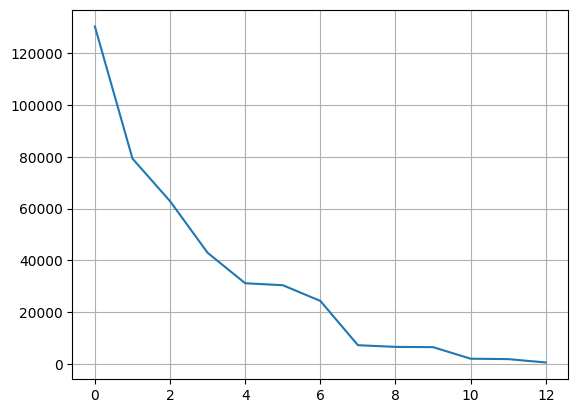

In [118]:
col = 'paint_color'
counts = df[col].fillna('others').value_counts()
plt.grid()
plt.plot(range(len(counts)),counts)

In [119]:
n_categorical = 7
others = counts.index[n_categorical:]
df[col]=df[col].apply(lambda s: s if str(s) not in others else 'others')

In [120]:
df[col].value_counts()

,count
paint_color,
white,79285
black,62861
silver,42970
blue,31223
red,30473
others,25449
grey,24416


In [121]:
df.loc[df[col]=='other',col] ='others'

In [122]:
df[col].fillna('others',inplace=True)

/tmp/ipykernel_767/1209704925.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('others',inplace=True)


### 문제 9. 수치형 데이터 시각화하여 분석하기

In [ ]:
# 수치형 데이터의 값의 범위, 기초 통계 분석하기


df.columns



Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'age'],
      dtype='object')

<Axes: xlabel='manufacturer', ylabel='price'>

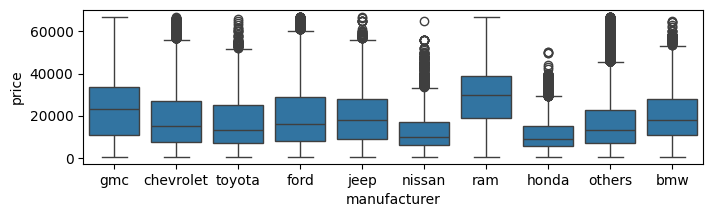

In [132]:
fig = plt.figure(figsize=(8,2))
sns.boxplot(x='manufacturer',y='price',data=df)

<Axes: xlabel='model', ylabel='price'>

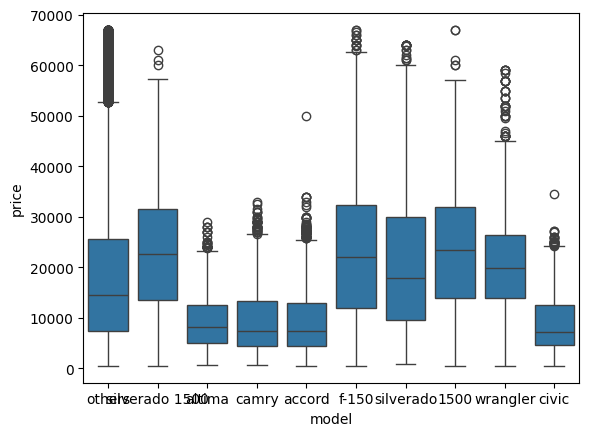

In [133]:
sns.boxplot(x='model',y='price',data =df)

### 문제 10. 수치형 데이터 클리닝하기

In [124]:
# quantile() 메소드를 이용하여 outlier 제거하고 시각화하여 확인하기

p1 = df['price'].quantile(0.99)
p2 = df['price'].quantile(0.1)
print(p1,p2)

66995.0 500.0


In [127]:
df= df[(p1>df['price']) & (df['price']>p2)]

In [126]:
o1 = df['odometer'].quantile(0.99)
o2 = df['odometer'].quantile(0.1)
print(o1,o2)

280000.0 14939.0


In [128]:
df= df[(o1>df['odometer']) & (df['odometer']>o2)]

In [129]:
df.describe()

,price,odometer,age
count,338073.000000,338073.000000,337457.000000
mean,17618.115265,100771.015355,15.204921
std,12678.374523,57120.746792,8.489158
min,501.000000,14940.000000,4.000000
25%,7495.000000,51933.000000,10.000000
50%,14599.000000,96281.000000,13.000000
75%,25590.000000,140000.000000,18.000000
max,66992.000000,279974.000000,126.000000


In [ ]:
# 수치형 데이터의 값의 범위, 기초 통계 분석하기


df.columns



Index(['region', 'price', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'size',
       'type', 'paint_color', 'age'],
      dtype='object')

<Axes: xlabel='manufacturer', ylabel='price'>

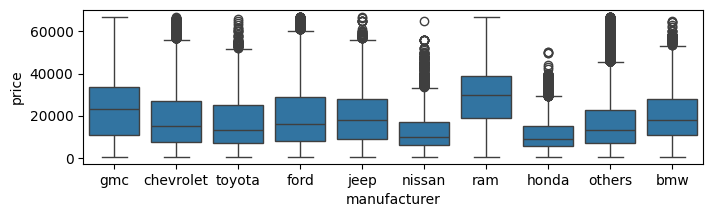

In [ ]:
fig = plt.figure(figsize=(8,2))
sns.boxplot(x='manufacturer',y='price',data=df)

<Axes: xlabel='model', ylabel='price'>

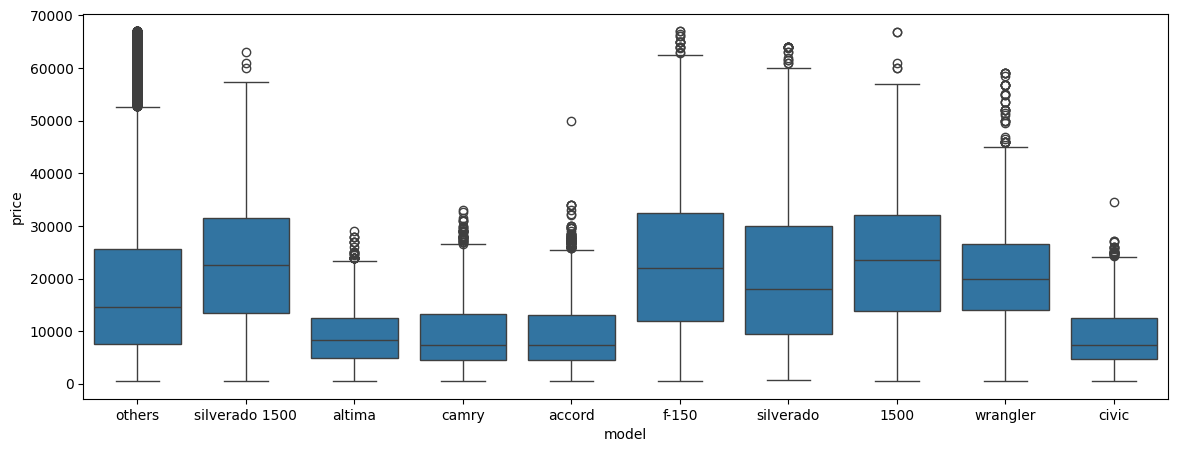

In [134]:
fig = plt.figure(figsize=(14,5))
sns.boxplot(x='model',y='price',data =df)

### 문제 11. 컬럼간의 Correlation Heatmap으로 시각화하기

<Axes: >

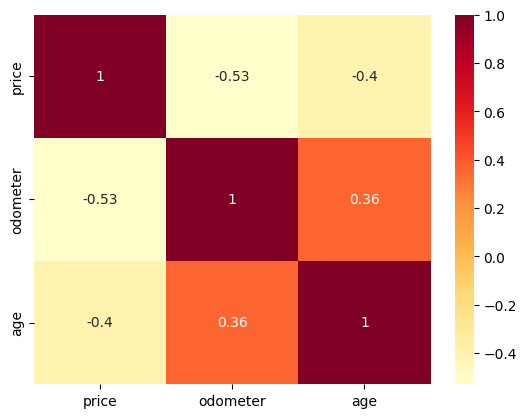

In [136]:
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='YlOrRd')

## Step 4. 모델 학습을 위한 데이터 전처리

### 문제 12. StandardScaler를 이용해 수치형 데이터 표준화하기


In [137]:
from sklearn.preprocessing import StandardScaler

In [139]:
# StandardScaler를 이용해 수치형 데이터를 표준화하기

X_num =df[['odometer','age']]
scaler = StandardScaler()
scaler.fit(X_num)
X_scaled = scaler.transform(X_num)
X_scaled = pd.DataFrame(X_scaled,index = X_num.index, columns=X_num.columns)
# get_dummies를 이용해 범주형 데이터를 one-hot 벡터로 변경하기
X_cat = df.drop(['price','odometer','age'],axis=1)
X_cat = pd.get_dummies(X_cat)
# 입출력 데이터 통합하기
X = pd.concat([X_scaled,X_cat],axis=1)
y = df['price']

In [142]:
X.shape

(338073, 59)

In [145]:
X.fillna(0.0,inplace=True)

### 문제 13. 학습데이터와 테스트데이터 분리하기


In [146]:
from sklearn.model_selection import train_test_split

In [147]:
# train_test_split() 함수로 학습 데이터와 테스트 데이터 분리하기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

## Step 5. Regression 모델 학습하기

### 문제 14. XGBoost Regression 모델 학습하기

In [148]:
from xgboost import XGBRegressor

In [149]:
# XGBRegressor 모델 생성/학습
model_reg = XGBRegressor()
model_reg.fit(X_train,y_train)




XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### 문제 15. 모델 학습 결과 평가하기

In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

In [151]:
# Predict를 수행하고 mean_absolute_error, rmse 결과 출력하기
pred = model_reg.predict(X_test)
print(mean_absolute_error(y_test,pred))
print(sqrt(mean_squared_error(y_test,pred)))





3769.6796875
5767.2388540791335


## Step 6. 모델 학습 결과 심화 분석하기


### 문제 16. 실제 값과 추측 값의 Scatter plot 시각화하기


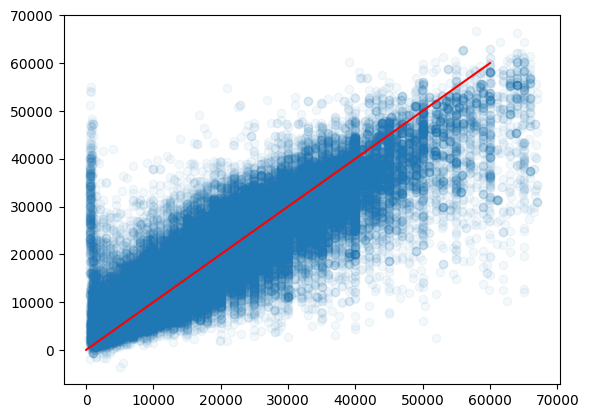

In [153]:
# y_test vs. pred Scatter 플랏으로 시각적으로 분석하기
# Hint) Scatter로 시각적 확인이 어려울 경우, histplot 등 활용

plt.scatter(x=y_test,y=pred,alpha=0.05)
plt.plot([0,60000],[0,60000],'r-')

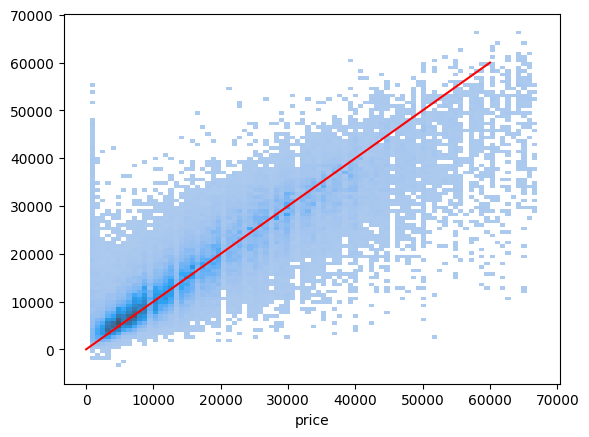

In [159]:
sns.histplot(x=y_test,y=pred)
plt.plot([0,60000],[0,60000],'r-')

### 문제 17. 에러 값의 히스토그램 확인하기


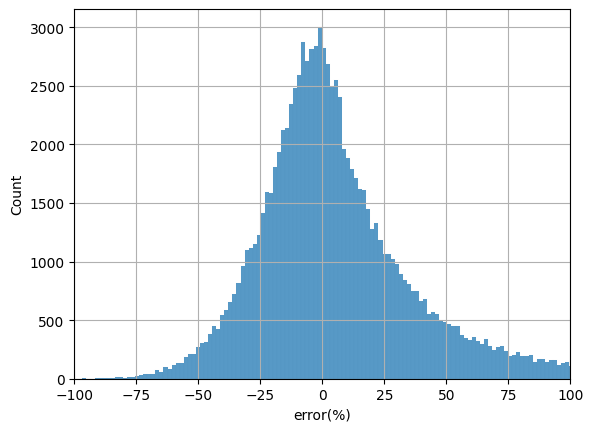

In [158]:
# err의 히스토그램으로 에러율 히스토그램 확인하기
err = (pred - y_test) / y_test *100
sns.histplot(err)
plt.xlabel('error(%)')
plt.xlim(-100,100)
plt.grid()

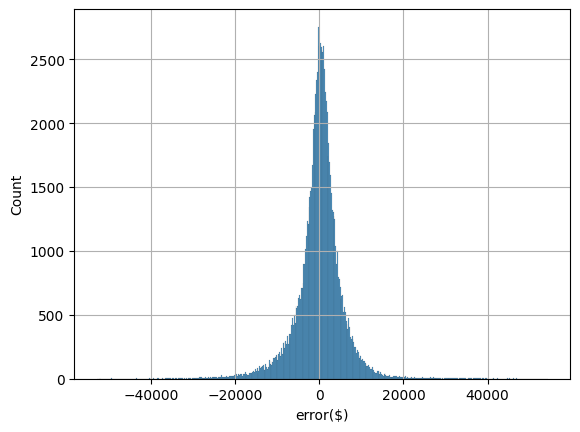

In [160]:
err = (pred - y_test)
sns.histplot(err)
plt.xlabel('error($)')
plt.grid()